In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.init as init
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import trange
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.style.use('seaborn-whitegrid')
import numpy as np

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda:0")
else:
    device = torch.device("cpu")
print("Device:", device)

Device: cuda:0


### Load MNIST dataset

In [3]:
# Define a transform to normalize the data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Download and load the training data
trainset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=True, transform=transform)
train_loader = DataLoader(trainset, batch_size=64, shuffle=True)

# Download and load the test data
testset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=False, transform=transform)
test_loader = DataLoader(testset, batch_size=64, shuffle=False)

### Build Model

In [4]:
def train_model(model, train_loader, test_loader, loss_fn, optimizer, epochs, device):
    train_errors = []
    test_errors = []
    train_accuracies = []
    test_accuracies = []

    tqdm_epoch = trange(epochs)
    for epoch in tqdm_epoch:
        model.train()
        train_loss = 0.0
        correct_train = 0

        # Training
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            # Forward pass
            outputs = model(batch_X)
            loss = loss_fn(outputs, batch_y)
            
            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * batch_X.size(0)
            # Calculate accuracy
            _, predicted = torch.max(outputs.data, 1)
            correct_train += (predicted == batch_y).sum().item()

        train_loss /= len(train_loader.dataset)
        train_accuracy = 100 * correct_train / len(train_loader.dataset)
        train_errors.append(train_loss)
        train_accuracies.append(train_accuracy)
        
        # Evaluation on test set
        model.eval()
        test_loss = 0.0
        correct_test = 0
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = loss_fn(outputs, batch_y)
                test_loss += loss.item() * batch_X.size(0)
                # Calculate accuracy
                _, predicted = torch.max(outputs.data, 1)
                correct_test += (predicted == batch_y).sum().item()

        test_loss /= len(test_loader.dataset)
        test_accuracy = 100 * correct_test / len(test_loader.dataset)
        test_errors.append(test_loss)
        test_accuracies.append(test_accuracy)

        tqdm_epoch.set_description(f"Epoch {epoch+1}/{epochs} \
            - Train loss: {train_loss:.4f}, Test loss: {test_loss:.4f}, \
            Train Acc: {train_accuracy:.2f}%, Test Acc: {test_accuracy:.2f}%")

    history = dict()
    history['train_loss'] = train_errors
    history['test_loss'] = test_errors
    history['train_acc'] = train_accuracies
    history['test_acc'] = test_accuracies
        
    return history

In [5]:
no_epochs = 50

In [6]:
class FashionMNISTCNN(nn.Module):
    def __init__(self):
        super(FashionMNISTCNN, self).__init__()
        
        # Define the layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3)
        self.fc1 = nn.Linear(64 * 3 * 3, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        # Apply layers and activations
        x = torch.relu(self.conv1(x))
        x = nn.MaxPool2d(2, 2)(x)
        x = torch.relu(self.conv2(x))
        x = nn.MaxPool2d(2, 2)(x)
        x = torch.relu(self.conv3(x))
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

### Train Model

In [7]:
model = FashionMNISTCNN().to(device)

In [9]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [10]:
model_dict = train_model(model, train_loader, test_loader,
                          loss_fn, optimizer, no_epochs, device)

  0%|          | 0/50 [00:00<?, ?it/s]

### Evaluate Model

In [14]:
features_list = []
labels_list = []

for batch in test_loader:
    features, labels = batch
    features_list.append(features)
    labels_list.append(labels)

test_x = torch.cat(features_list, dim=0).to(device)
test_y = torch.cat(labels_list, dim=0).to(device)

In [15]:
y_predict = model(test_x)

In [20]:
y_pred = torch.argmax(y_predict, dim=1)

In [26]:
pred = y_pred.detach().cpu().numpy()
true = test_y.detach().cpu().numpy() 

In [27]:
# Accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(true, pred)
print("Accuracy = {}".format(accuracy))

Accuracy = 0.9088


In [28]:
# Balanced Accuracy
from sklearn.metrics import balanced_accuracy_score
balanced_accuracy = balanced_accuracy_score(true, pred)
print("Balanced Accuracy = {}".format(balanced_accuracy))

Balanced Accuracy = 0.9088


In [29]:
# Macro Precision
from sklearn.metrics import precision_score
maprecision = precision_score(true, pred, average='macro')
print("Macro Precision = {}".format(maprecision))

Macro Precision = 0.9092881638234569


In [30]:
# Weighted Precision
from sklearn.metrics import precision_score
wprecision = precision_score(true, pred, average='weighted')
print("Weighted Precision = {}".format(wprecision))

Weighted Precision = 0.9092881638234569


In [31]:
# Macro Recall
from sklearn.metrics import recall_score
marecall = recall_score(true, pred, average='macro')
print("Macro Recall = {}".format(marecall))

Macro Recall = 0.9088


In [32]:
# Micro Recall
from sklearn.metrics import recall_score
mirecall = recall_score(true, pred, average='micro')
print("Micro Recall = {}".format(mirecall))

Micro Recall = 0.9088


In [33]:
# Weighted Recall
from sklearn.metrics import recall_score
wrecall = recall_score(true, pred, average='weighted')
print("Weighted Recall = {}".format(wrecall))

Weighted Recall = 0.9088


In [34]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

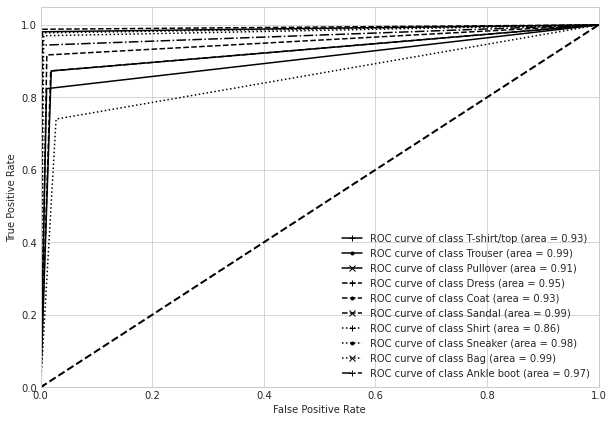

In [39]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the output
y_true_binary = label_binarize(true, classes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
y_pred_binary = label_binarize(pred, classes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
n_classes = y_true_binary.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_binary[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
fig, ax = plt.subplots(figsize=(10,7))
from cycler import cycler
monochrome = (cycler('color', ['k']) * cycler('linestyle', ['-', '--', ':', '-.']) * cycler('marker', ['+', '.', 'x']))
ax.set_prop_cycle(monochrome)
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], markevery=20,
             label='ROC curve of class {0} (area = {1:0.2f})'
                   ''.format(class_names[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
fig.savefig('MulticlassROC.png', dpi=300, bbox_inches='tight')  
plt.show()

In [40]:
# Plot Confusion Matrix
import seaborn as sn
from sklearn.metrics import confusion_matrix
import pandas as pd

In [41]:
cm = confusion_matrix(true, pred)

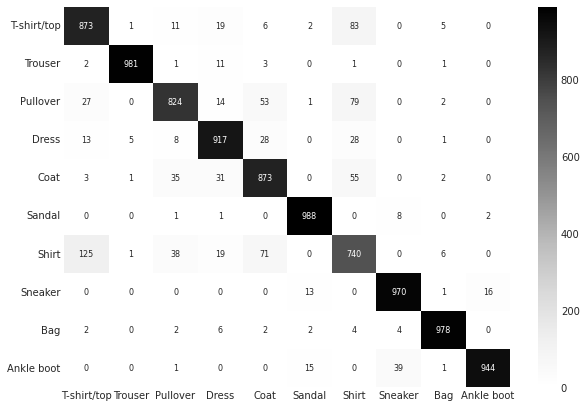

In [42]:
df_cm = pd.DataFrame(cm, class_names, class_names)
fig, ax = plt.subplots(figsize=(10,7))

sn.heatmap(df_cm, cmap='Greys', annot=True, annot_kws={"size": 8}, fmt='d') # font size
fig.savefig('MulticlassCM.png', dpi=300, bbox_inches='tight') 